# Node-Assigned PINN for 6-Tank Thermal-Hydraulic Simulation

Reproduction of **Shin et al. (2026)** — *Progress in Nuclear Energy* **197**, 106411  
**Goal:** Reproduce **Fig. 14 (e) Height profile** and **(f) Velocity profile** for the 6-CV scenario using **Vanilla PINN**, **LP-PINN**, and **NA-PINN**.

### How to run
1. `Runtime ▸ Change runtime type ▸ GPU` (T4 / A100 / L4 all OK)
2. `Runtime ▸ Run all`
3. Full training (50,000 epochs, full network sizes from Tables 7 & 9) takes roughly **30–60 min** on a T4 GPU.
   - To smoke-test the pipeline first, set `QUICK = True` in the config cell below; it finishes in a few minutes.

In [ ]:
# Colab usually has these already, so this is a no-op most of the time.
# !pip install torch numpy matplotlib --quiet

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time, math

# Reproducibility
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('[INFO] Using device:', device)

# Toggle: True = quick smoke test, False = full paper-scale training
QUICK = False

[INFO] Using device: cuda


## 1. Physical constants & 6-Tank scenario settings

In [ ]:
g       = 9.81
rho     = 1000.0
A_t     = 50.0                         # tank area [m^2]
A_p     = math.pi * (0.2/2)**2          # FL cross-section [m^2]
L_pipe  = 0.1                           # FL length [m]
K_loss  = 1.0                           # net form/wall-loss coefficient
#K_loss  = 5.0                           # net form/wall-loss coefficient
F_open  = 1.0
H_tank  = 2.0
elev_step = 1.8                         # elevation step between consecutive tanks

N_i = 6
N_j = N_i - 1
T_END = 2800.0                          # PINN training horizon [s]

## 2. Python emulator — Algorithms 1 & 2 (reference solver)

Running emulator …
  finished. final t = 2800 s, steps = 2801
  final H = [0.003 0.008 0.013 0.019 0.078 1.878]
[0.000e+00 1.000e+00 2.000e+00 ... 2.798e+03 2.799e+03 2.800e+03]


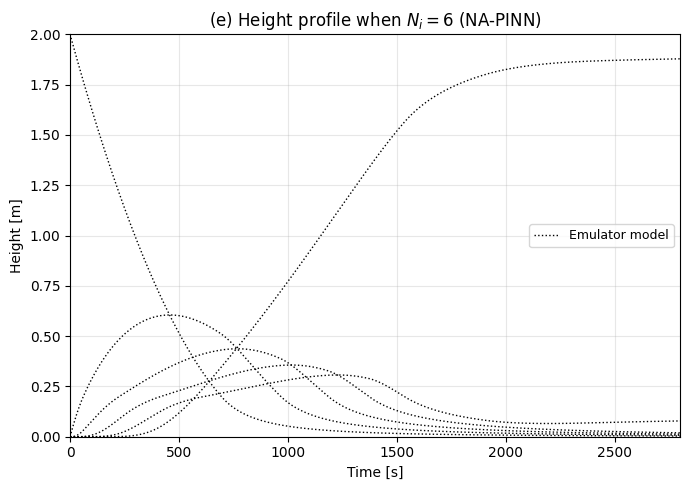

In [ ]:
def void_fraction(H_d):
    if H_d >= 0.2:   return 0.0
    if H_d <= 0.0:   return 1.0
    return 1.0 - H_d/0.2

def velocity_iteration(v_o, alpha, alpha_o, dz, dt, K, rho_, L, Ap, At):
    v_n_minus = v_o
    v_o2 = v_o + (alpha_o - alpha) * (-v_o)
    v_max = math.sqrt(2.0 * g * max(dz, 1e-6))# generous physical cap
    #v_max = math.sqrt(2.0 * g * max(dz, 1e-6)) * 2.0  # generous physical cap
    for _ in range(200):
        num = v_o2 + dt/L*(g*dz + v_o2**2 * Ap/At) + (K*dt)/(2*L)*(v_n_minus**2)
        den = 1.0 + (K*dt)/(2*L)*(v_o + v_n_minus) + dt/L*v_o2*Ap/At
        v_n_plus = num/den
        v_n_plus = max(0.0, min(v_n_plus, v_max))
        if abs(v_n_plus - v_n_minus) < 0.09 * abs(v_n_minus + 1e-12):
            return v_n_plus
        v_n_minus = v_n_plus
    return v_n_plus

def run_emulator(t_end=2800.0, dt=1.0):
    n_steps = int(t_end/dt) + 1
    times = np.arange(n_steps) * dt
    H = np.zeros((n_steps, N_i))
    V = np.zeros((n_steps, N_j))
    masses = np.zeros(N_i)
    masses[0] = rho * A_t * H_tank
    H[0,0] = H_tank
    elev = np.array([(N_i-1-i)*elev_step for i in range(N_i)])
    alphas = np.ones(N_j)
    for n in range(1, n_steps):
        new_masses = masses.copy()
        v_news = np.zeros(N_j)
        new_alphas = alphas.copy()
        for j in range(N_j):
            d, r = j, j+1
            H_d_local = masses[d] / (rho*A_t)
            H_r_local = masses[r] / (rho*A_t)
            if H_d_local <= 1e-6:
                v_news[j] = 0.0; new_alphas[j] = 1.0; continue
            if H_r_local < elev_step:
                dz = H_d_local
            else:
                dz = H_d_local + elev_step - H_r_local
            if dz <= 0:
                v_news[j] = 0.0; new_alphas[j] = void_fraction(H_d_local); continue
            alpha_new = void_fraction(H_d_local)
            v_new = velocity_iteration(V[n-1,j], alpha_new, alphas[j],
                                       dz, dt, K_loss, rho, L_pipe, A_p, A_t)
            v_news[j] = max(v_new, 0.0)
            new_alphas[j] = alpha_new
        for j in range(N_j):
            d, r = j, j+1
            dm = rho * v_news[j] * dt * A_p * (1.0 - new_alphas[j])
            dm = min(dm, masses[d])
            new_masses[d] -= dm
            new_masses[r] += dm
        masses = new_masses; alphas = new_alphas
        V[n,:] = v_news
        H[n,:] = masses / (rho*A_t)
        if (abs(H[n,-1]+elev[-1]-(H[n,-2]+elev[-2])) < 1e-3 and n > 100
                and abs(V[n,-1]) < 1e-3):
            return times[:n+1], H[:n+1], V[:n+1]
    return times, H, V

print('Running emulator …')
#T_END = 28000.0
em_t, em_H, em_V = run_emulator(t_end=2800.0, dt=1.0)
print(f'  finished. final t = {em_t[-1]:.0f} s, steps = {len(em_t)}')
print(f'  final H = {em_H[-1].round(3)}')
print(em_t)

colors    = ['tab:orange','tab:red','tab:green','tab:blue','tab:olive','tab:purple']
fl_colors = ['tab:red','tab:green','tab:blue','tab:purple','tab:orange']

fig, ax = plt.subplots(figsize=(7, 5))

for i in range(N_i):
    ax.plot(em_t, em_H[:, i], 'k:', lw=1.0,
            label='Emulator model' if i == 0 else None)
    #ax.plot(em_t, H_na[:,i], '-', color=colors[i], label=f'CV0{i+1}', lw=1.5)
ax.set_title('(e) Height profile when $N_i = 6$ (NA-PINN)')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Height [m]')
ax.set_xlim(0, em_t[-1]); ax.set_ylim(0, 2.0)
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Fig14_ef_NA_PINN_6Tank.png', dpi=200)
plt.show()

## 3. Common neural network components

In [ ]:
class FCN(nn.Module):
    def __init__(self, in_dim, out_dim, hidden, layers):
        super().__init__()
        seq = [nn.Linear(in_dim, hidden), nn.ELU()]
        for _ in range(layers-1):
            seq += [nn.Linear(hidden, hidden), nn.ELU()]
        seq += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*seq)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

def void_alpha_torch(H):
    return torch.where(H >= 0.2, torch.zeros_like(H),
                       torch.clamp(1.0 - H/0.2, 0.0, 1.0))

## 4. Vanilla PINN — input = (t, i)

In [ ]:
class VanillaPINN(nn.Module):
    def __init__(self, hidden=368, layers=10):
        super().__init__()
        self.net = FCN(in_dim=2, out_dim=2, hidden=hidden, layers=layers)
    def forward(self, t_norm, i_idx):
        return self.net(torch.cat([t_norm, i_idx], dim=1))

def train_vanilla_pinn(epochs, n_coll, hidden, layers):
    print('=== Vanilla PINN ===')
    model = VanillaPINN(hidden=hidden, layers=layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9999)
    H0 = torch.tensor([2.0,0.,0.,0.,0.,0.], device=device)
    losses = []
    t_start = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        t_coll = torch.linspace(0.0, T_END, n_coll, device=device).reshape(-1,1).requires_grad_(True)
        t_norm = t_coll / T_END
        t_norm_tiled = t_norm.repeat(N_i, 1)
        i_tiled = torch.arange(1, N_i+1, device=device).float() \
                       .repeat_interleave(n_coll).reshape(-1,1)
        out = model(t_norm_tiled, i_tiled)
        with torch.no_grad():
            t0 = torch.zeros(N_i, 1, device=device)
            i0 = torch.arange(1, N_i+1, device=device).float().reshape(-1,1)
            out0 = model(t0, i0)
        out = out.view(N_i, n_coll, 2)
        H = (out[:,:,0] - out0[:,0:1] + H0.view(N_i,1)).T
        V_full = (out[:,:,1] - out0[:,1:2]).T
        V = V_full[:, :N_j]
        dHdt = torch.cat([torch.autograd.grad(H[:,i].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for i in range(N_i)], dim=1)
        dVdt = torch.cat([torch.autograd.grad(V[:,j].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for j in range(N_j)], dim=1)
        H_d = H[:,:-1]; H_r = H[:,1:]
        dz = torch.where(H_r < elev_step, H_d, torch.clamp(H_d+elev_step-H_r, min=0.0))
        mom_res = L_pipe*dVdt - g*dz + 0.5*K_loss*torch.abs(V)*V
        loss_mom = (mom_res**2).mean()
        alpha = void_alpha_torch(H_d)
        flux = rho*A_p*F_open*V*(1.0 - alpha)
        cont_res = torch.zeros_like(H)
        cont_res[:,0]    = rho*A_t*dHdt[:,0]    + flux[:,0]
        cont_res[:,-1]   = rho*A_t*dHdt[:,-1]   - flux[:,-1]
        cont_res[:,1:-1] = rho*A_t*dHdt[:,1:-1] + flux[:,1:] - flux[:,:-1]
        loss_cont = (cont_res**2).mean()
        loss = loss_mom + 1e-3 * loss_cont
        loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
        if (ep+1) % max(1, epochs//25) == 0:
            print(f'  ep {ep+1:6d}/{epochs} loss={loss.item():.3e} mom={loss_mom.item():.3e} cont={loss_cont.item():.3e}')
    print(f'  trained in {time.time()-t_start:.1f} s')
    return model, losses

@torch.no_grad()
def predict_vanilla(model, times):
    t = torch.tensor(times, device=device, dtype=torch.float32).reshape(-1,1)
    t_norm = t / T_END
    t_zero = torch.zeros_like(t_norm)
    H0 = torch.tensor([2.0,0.,0.,0.,0.,0.], device=device)
    H_arr = np.zeros((len(times), N_i))
    V_arr = np.zeros((len(times), N_j))
    for i in range(N_i):
        i_col = torch.full_like(t_norm, float(i+1))
        out = model(t_norm, i_col); out0 = model(t_zero, i_col)
        H_arr[:,i] = (out[:,0] - out0[:,0] + H0[i]).cpu().numpy()
        if i < N_j:
            V_arr[:,i] = (out[:,1] - out0[:,1]).cpu().numpy()
    return H_arr, V_arr

## 5. LP-PINN — single net, output = (h₁..h₆, v₁..v₅)

In [ ]:
class LPPINN(nn.Module):
    def __init__(self, hidden=368, layers=10):
        super().__init__()
        self.net = FCN(in_dim=1, out_dim=2*N_i-1, hidden=hidden, layers=layers)
    def forward(self, t):
        return self.net(t)

def train_lp_pinn(epochs, n_coll, hidden, layers):
    print('=== LP-PINN ===')
    model = LPPINN(hidden=hidden, layers=layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9999)
    u0 = torch.cat([torch.tensor([2.0,0.,0.,0.,0.,0.], device=device),
                    torch.zeros(N_j, device=device)])
    losses = []
    t_start = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        t_coll = torch.linspace(0.0, T_END, n_coll, device=device).reshape(-1,1).requires_grad_(True)
        t_norm = t_coll / T_END
        t_zero = torch.zeros_like(t_norm)
        u  = model(t_norm) - model(t_zero) + u0
        H = u[:, :N_i]; V = u[:, N_i:]
        dHdt = torch.cat([torch.autograd.grad(H[:,i].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for i in range(N_i)], dim=1)
        dVdt = torch.cat([torch.autograd.grad(V[:,j].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for j in range(N_j)], dim=1)
        H_d = H[:,:-1]; H_r = H[:,1:]
        dz = torch.where(H_r < elev_step, H_d, torch.clamp(H_d+elev_step-H_r, min=0.0))
        mom_res = L_pipe*dVdt - g*dz + 0.5*K_loss*torch.abs(V)*V
        loss_mom = (mom_res**2).mean()
        alpha = void_alpha_torch(H_d)
        flux = rho*A_p*F_open*V*(1.0-alpha)
        cont_res = torch.zeros_like(H)
        cont_res[:,0]    = rho*A_t*dHdt[:,0]    + flux[:,0]
        cont_res[:,-1]   = rho*A_t*dHdt[:,-1]   - flux[:,-1]
        cont_res[:,1:-1] = rho*A_t*dHdt[:,1:-1] + flux[:,1:] - flux[:,:-1]
        loss_cont = (cont_res**2).mean()
        loss = loss_mom + 1e-3*loss_cont
        loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
        if (ep+1) % max(1, epochs//25) == 0:
            print(f'  ep {ep+1:6d}/{epochs} loss={loss.item():.3e} mom={loss_mom.item():.3e} cont={loss_cont.item():.3e}')
    print(f'  trained in {time.time()-t_start:.1f} s')
    return model, losses

@torch.no_grad()
def predict_lp(model, times):
    t = torch.tensor(times, device=device, dtype=torch.float32).reshape(-1,1)
    t_norm = t/T_END
    u0 = torch.cat([torch.tensor([2.0,0.,0.,0.,0.,0.], device=device),
                    torch.zeros(N_j, device=device)])
    out = model(t_norm) - model(torch.zeros_like(t_norm)) + u0
    return out[:,:N_i].cpu().numpy(), out[:,N_i:].cpu().numpy()

## 6. NA-PINN — one subnetwork per node (11 subnets for 6-CV)

In [ ]:
class NAPINN(nn.Module):
    def __init__(self, hidden=128, layers=8):
        super().__init__()
        self.H_nets = nn.ModuleList([FCN(1,1,hidden,layers) for _ in range(N_i)])
        self.V_nets = nn.ModuleList([FCN(1,1,hidden,layers) for _ in range(N_j)])
    def forward(self, t):
        H = torch.cat([n(t) for n in self.H_nets], dim=1)
        V = torch.cat([n(t) for n in self.V_nets], dim=1)
        return H, V

def train_na_pinn(epochs, n_coll, hidden, layers):
    print('=== NA-PINN ===')
    model = NAPINN(hidden=hidden, layers=layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9999)
    H0 = torch.tensor([2.0,0.,0.,0.,0.,0.], device=device)
    V0 = torch.zeros(N_j, device=device)
    losses = []
    t_start = time.time()
    for ep in range(epochs):
        opt.zero_grad()
        t_coll = torch.linspace(0.0, T_END, n_coll, device=device).reshape(-1,1).requires_grad_(True)
        t_norm = t_coll/T_END
        t_zero = torch.zeros_like(t_norm)
        H_raw, V_raw = model(t_norm)
        H_raw0, V_raw0 = model(t_zero)
        H = H_raw - H_raw0 + H0
        V = V_raw - V_raw0 + V0
        dHdt = torch.cat([torch.autograd.grad(H[:,i].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for i in range(N_i)], dim=1)
        dVdt = torch.cat([torch.autograd.grad(V[:,j].sum(), t_coll,
                                              create_graph=True, retain_graph=True)[0]
                          for j in range(N_j)], dim=1)
        H_d = H[:,:-1]; H_r = H[:,1:]
        dz = torch.where(H_r < elev_step, H_d, torch.clamp(H_d+elev_step-H_r, min=0.0))
        mom_res = L_pipe*dVdt - g*dz + 0.5*K_loss*torch.abs(V)*V
        loss_mom = (mom_res**2).mean()
        alpha = void_alpha_torch(H_d)
        flux = rho*A_p*F_open*V*(1.0-alpha)
        cont_res = torch.zeros_like(H)
        cont_res[:,0]    = rho*A_t*dHdt[:,0]    + flux[:,0]
        cont_res[:,-1]   = rho*A_t*dHdt[:,-1]   - flux[:,-1]
        cont_res[:,1:-1] = rho*A_t*dHdt[:,1:-1] + flux[:,1:] - flux[:,:-1]
        loss_cont = (cont_res**2).mean()
        loss = loss_mom + 1e-3*loss_cont
        loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
        if (ep+1) % max(1, epochs//25) == 0:
            print(f'  ep {ep+1:6d}/{epochs} loss={loss.item():.3e} mom={loss_mom.item():.3e} cont={loss_cont.item():.3e}')
    print(f'  trained in {time.time()-t_start:.1f} s')
    return model, losses

@torch.no_grad()
def predict_na(model, times):
    t = torch.tensor(times, device=device, dtype=torch.float32).reshape(-1,1)
    t_norm = t/T_END
    H0 = torch.tensor([2.0,0.,0.,0.,0.,0.], device=device)
    V0 = torch.zeros(N_j, device=device)
    H_raw, V_raw = model(t_norm)
    H_raw0, V_raw0 = model(torch.zeros_like(t_norm))
    return ((H_raw-H_raw0+H0).cpu().numpy(),
            (V_raw-V_raw0+V0).cpu().numpy())

## 7. Train all three models

In [ ]:
QUICK = True
# Hyperparameters (Tables 7 & 9 of the paper, 6-CV column)
if QUICK:
    EPOCHS_VAN = EPOCHS_LP = EPOCHS_NA = 10000
    N_COLL = 1500
    H_VAN, L_VAN = 64, 4
    H_LP,  L_LP  = 64, 4
    H_NA,  L_NA  = 64, 4
else:
    EPOCHS_VAN = EPOCHS_LP = EPOCHS_NA = 50000
    N_COLL = 6000
    H_VAN, L_VAN = 368, 10   # Table 7
    H_LP,  L_LP  = 368, 10   # similar capacity
    H_NA,  L_NA  = 128, 8    # Table 9

van_model, van_loss = train_vanilla_pinn(EPOCHS_VAN, N_COLL, H_VAN, L_VAN)
lp_model,  lp_loss  = train_lp_pinn(EPOCHS_LP,  N_COLL, H_LP,  L_LP)
na_model,  na_loss  = train_na_pinn(EPOCHS_NA,  N_COLL, H_NA,  L_NA)

=== Vanilla PINN ===
  ep    400/10000 loss=1.482e+02 mom=1.449e+02 cont=3.302e+03
  ep    800/10000 loss=6.463e+01 mom=6.382e+01 cont=8.043e+02
  ep   1200/10000 loss=1.107e+02 mom=1.088e+02 cont=1.845e+03
  ep   1600/10000 loss=4.299e+01 mom=4.157e+01 cont=1.418e+03
  ep   2000/10000 loss=1.976e+01 mom=1.846e+01 cont=1.295e+03
  ep   2400/10000 loss=1.879e+01 mom=1.770e+01 cont=1.094e+03
  ep   2800/10000 loss=1.903e+01 mom=1.802e+01 cont=1.003e+03
  ep   3200/10000 loss=1.940e+01 mom=1.836e+01 cont=1.042e+03
  ep   3600/10000 loss=1.911e+01 mom=1.822e+01 cont=8.901e+02
  ep   4000/10000 loss=1.470e+01 mom=1.374e+01 cont=9.620e+02
  ep   4400/10000 loss=1.169e+01 mom=1.096e+01 cont=7.282e+02
  ep   4800/10000 loss=3.098e+01 mom=2.894e+01 cont=2.042e+03
  ep   5200/10000 loss=8.890e+00 mom=8.052e+00 cont=8.381e+02
  ep   5600/10000 loss=9.276e+00 mom=8.296e+00 cont=9.796e+02
  ep   6000/10000 loss=8.087e+00 mom=7.048e+00 cont=1.039e+03
  ep   6400/10000 loss=1.034e+01 mom=8.911e+00 co

In [ ]:
K_loss

1.0

## 8. Reproduce Fig. 14 (e) and (f)

NA-PINN vs Emulator (6-Tank)
  H : MAE=2.010e-02  MSE=9.170e-04
  V : MAE=1.506e-01  MSE=4.110e-02


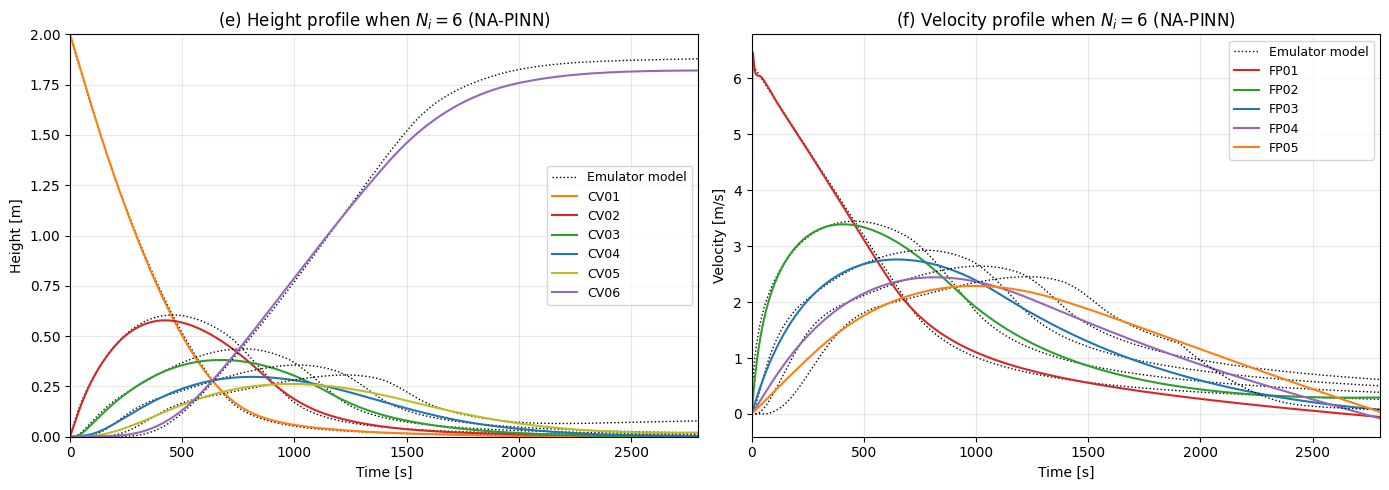

In [ ]:
H_van, V_van = predict_vanilla(van_model, em_t)
H_lp,  V_lp  = predict_lp(lp_model,  em_t)
H_na,  V_na  = predict_na(na_model,  em_t)

mae_H = np.mean(np.abs(H_na - em_H));  mse_H = np.mean((H_na - em_H)**2)
mae_V = np.mean(np.abs(V_na - em_V));  mse_V = np.mean((V_na - em_V)**2)
print('NA-PINN vs Emulator (6-Tank)')
print(f'  H : MAE={mae_H:.3e}  MSE={mse_H:.3e}')
print(f'  V : MAE={mae_V:.3e}  MSE={mse_V:.3e}')

colors    = ['tab:orange','tab:red','tab:green','tab:blue','tab:olive','tab:purple']
fl_colors = ['tab:red','tab:green','tab:blue','tab:purple','tab:orange']

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ax = axes[0]
for i in range(N_i):
    ax.plot(em_t, em_H[:,i], 'k:', lw=1.0,
            label='Emulator model' if i==0 else None)
    ax.plot(em_t, H_na[:,i], '-', color=colors[i], label=f'CV0{i+1}', lw=1.5)
ax.set_title('(e) Height profile when $N_i = 6$ (NA-PINN)')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Height [m]')
ax.set_xlim(0, em_t[-1]); ax.set_ylim(0, 2.0)
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for j in range(N_j):
    ax.plot(em_t, em_V[:,j], 'k:', lw=1.0,
            label='Emulator model' if j==0 else None)
    ax.plot(em_t, V_na[:,j], '-', color=fl_colors[j], label=f'FP0{j+1}', lw=1.5)
ax.set_title('(f) Velocity profile when $N_i = 6$ (NA-PINN)')
ax.set_xlabel('Time [s]'); ax.set_ylabel('Velocity [m/s]')
ax.set_xlim(0, em_t[-1])
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Fig14_ef_NA_PINN_6Tank.png', dpi=200)
plt.show()

## 9. (Bonus) Side-by-side comparison of all three architectures

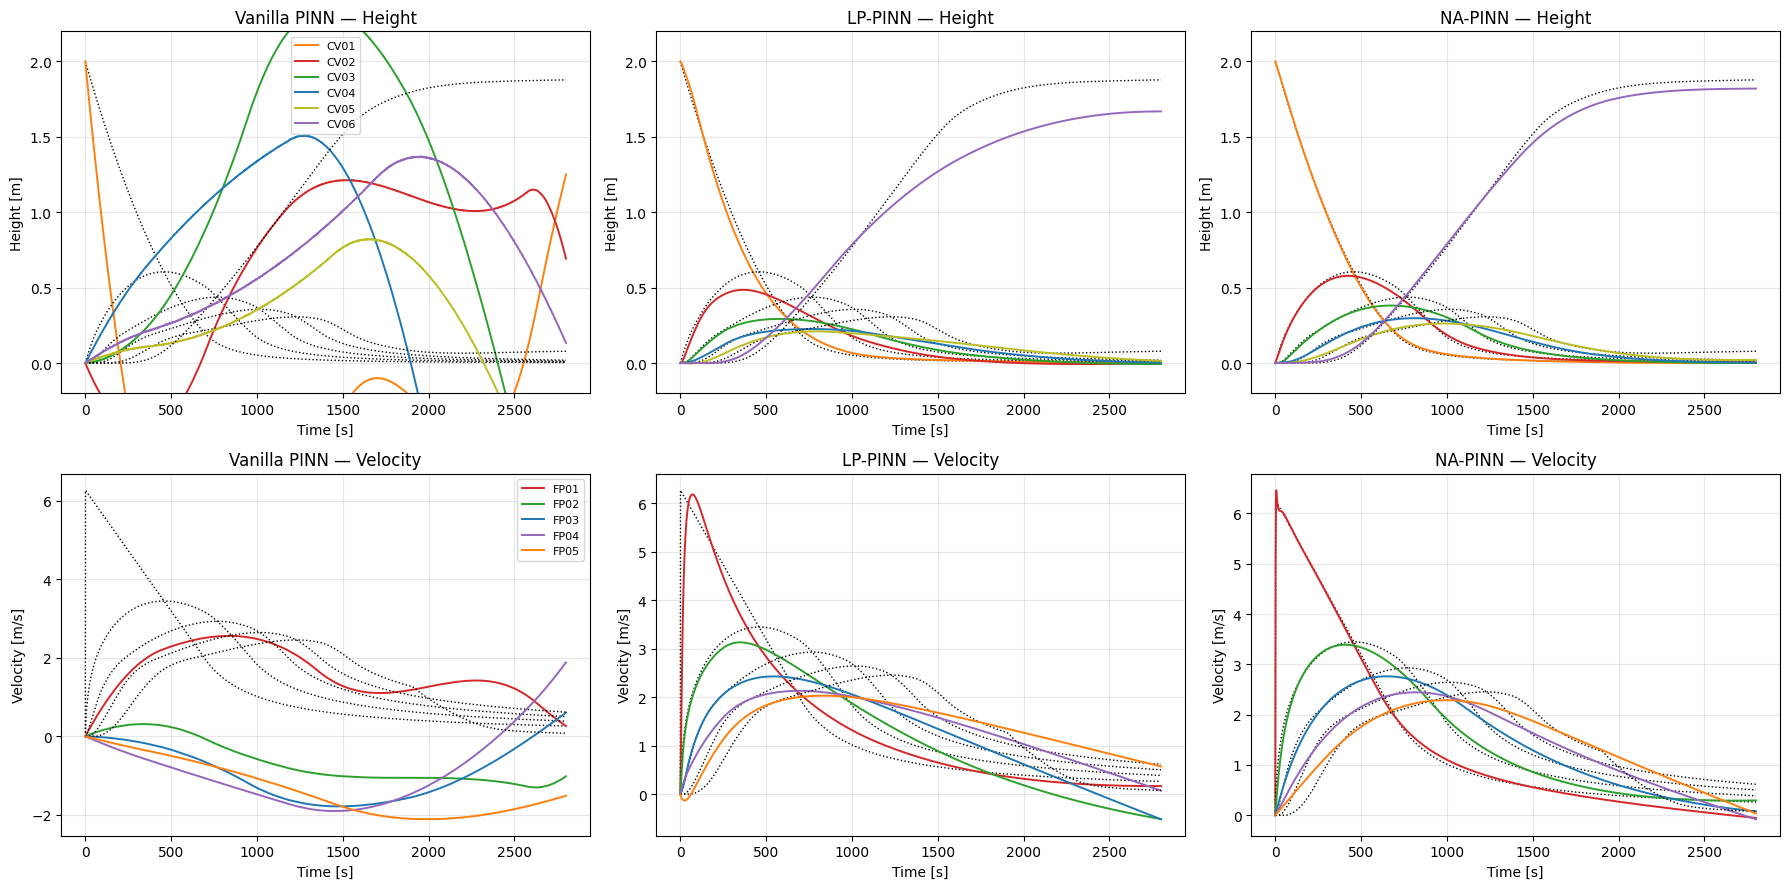

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,9))
for k, (name, Hp, Vp) in enumerate([('Vanilla PINN', H_van, V_van),
                                     ('LP-PINN',      H_lp,  V_lp),
                                     ('NA-PINN',      H_na,  V_na)]):
    ax = axes[0, k]
    for i in range(N_i):
        ax.plot(em_t, em_H[:,i], 'k:', lw=1.0)
        ax.plot(em_t, Hp[:,i], color=colors[i], lw=1.4, label=f'CV0{i+1}')
    ax.set_title(f'{name} — Height')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Height [m]')
    ax.set_ylim(-0.2, 2.2); ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=8)
    ax = axes[1, k]
    for j in range(N_j):
        ax.plot(em_t, em_V[:,j], 'k:', lw=1.0)
        ax.plot(em_t, Vp[:,j], color=fl_colors[j], lw=1.4, label=f'FP0{j+1}')
    ax.set_title(f'{name} — Velocity')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Velocity [m/s]')
    ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('Comparison_3PINNs_6Tank.png', dpi=200)
plt.show()